In [1]:
!pip -q install pytorch-forecasting lightning optuna shap xgboost openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 45.7 MB/s eta 0:00:00


In [2]:
import os
import re
import gc
import glob
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import CSVLogger

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

import optuna
import shap
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from google.colab import drive
drive.mount("/content/drive", force_remount=True)

BASE_DIR = Path("/content/drive/MyDrive")

OUTPUT_DIR = BASE_DIR / "model_6_tft_v2_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SALES_FILE = BASE_DIR / "model_ready_category_dataset.csv"

if not SALES_FILE.exists():
    raise FileNotFoundError(
        f"Main dataset not found: {SALES_FILE}\n"
        "Check that model_ready_category_dataset.csv exists in MyDrive."
    )

TRENDS_IT_PATH = BASE_DIR
TRENDS_ES_PATH = BASE_DIR

print("Google Drive mounted successfully.")
print("BASE_DIR:", BASE_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("SALES_FILE:", SALES_FILE)
print("TRENDS_IT_PATH:", TRENDS_IT_PATH)
print("TRENDS_ES_PATH:", TRENDS_ES_PATH)

print("\nChecking key files:")
print("Main dataset exists:", SALES_FILE.exists())

trend_files = sorted(BASE_DIR.glob("*google trends*.csv"))
print("Google Trends files found:", len(trend_files))

for f in trend_files[:10]:
    print(" -", f.name)

if len(trend_files) == 0:
    raise FileNotFoundError("No Google Trends CSV files found in MyDrive.")

Mounted at /content/drive
Google Drive mounted successfully.
BASE_DIR: /content/drive/MyDrive
OUTPUT_DIR: /content/drive/MyDrive/model_6_tft_v2_outputs
SALES_FILE: /content/drive/MyDrive/model_ready_category_dataset.csv
TRENDS_IT_PATH: /content/drive/MyDrive
TRENDS_ES_PATH: /content/drive/MyDrive

Checking key files:
Main dataset exists: True
Google Trends files found: 65
 - abrigo piel_google trends_Spain.csv
 - berretto uomo_google trends_Italy.csv
 - berretto uomo_google trends_italy.csv
 - berretto_google trends_Italy.csv
 - blusa_google trends_Spain.csv
 - bolsa playa_google trends_Spain.csv
 - bolsa viaje mochila_google trends_Spain.csv
 - bolso hombre_google trends_Spain.csv
 - bolso mujer_google trends_Spain.csv
 - borsa donna_google trends_Italy.csv


In [3]:
ITALY_TRENDS_FILES = {
    'borsa donna': 'borsa donna_google trends_Italy.csv',
    'portafoglio donna': 'portafoglio donna_google trends_Italy.csv',
    'portafoglio uomo': 'portafoglio uomo_google trends_Italy.csv',
    'guanti donna': 'guanti donna_google trends_Italy.csv',
    'guanti uomo': 'guanti uomo_google trends_Italy.csv',
    'sciarpa': 'sciarpa_google trends_Italy.csv',
    'sciarpa uomo': 'sciarpa uomo_google trends_Italy.csv',
    'stola': 'stola_google trends_Italy.csv',
    'cappello': 'cappello_google trends_Italy.csv',
    'berretto': 'berretto_google trends_Italy.csv',
    'berretto uomo': 'berretto uomo_google trends_Italy.csv',
    'borsa mare': 'borsa mare_google trends_Italy.csv',
    'borsa uomo': 'borsa uomo_google trends_Italy.csv',
    'telo mare': 'telo mare_google trends_Italy.csv',
    'scarpe donna': 'scarpe donna_google trends_Italy.csv',
    'pelliccia cappotto': 'pelliccia cappotto_google trends_Italy.csv',
    'cintura donna': 'cintura donna_google trends_Italy.csv',
    'cintura uomo': 'cintura uomo_google trends_Italy.csv',
    'vestito donna': 'vestito donna_google trends_Italy.csv',
    'vestito': 'vestito_google trends_Italy.csv',
    'tunica': 'tunica_google trends_Italy.csv',
    'gonna': 'gonna_google trends_Italy.csv',
    'camicia': 'camicia_google trends_Italy.csv',
    'camicetta': 'camicetta_google trends_Italy.csv',
    'pantaloni': 'pantaloni_google trends_Italy.csv',
    'pantaloncini': 'pantaloncini_google trends_Italy.csv',
    'pareo': 'pareo_google trends_Italy.csv',
    'cappa': 'cappa_google trends_Italy.csv',
    'caftano': 'caftano_google trends_Italy.csv',
    'portachiavi': 'portachiavi_google trends_Italy.csv',
    'borsa viaggio zaino': 'borsa viaggio zaino_google trends_Italy.csv',
    'pelletteria accessori': 'pelletteria accessori_google trends_Italy.csv',
}

SPAIN_TRENDS_FILES = {
    'bolso mujer': 'bolso mujer_google trends_Spain.csv',
    'bolso hombre': 'bolso hombre_google trends_Spain.csv',
    'cartera mujer': 'cartera mujer_google trends_Spain.csv',
    'cartera hombre': 'cartera hombre_google trends_Spain.csv',
    'guantes mujer': 'guantes mujer_google trends_Spain.csv',
    'guantes hombre': 'guantes hombre_google trends_Spain.csv',
    'ecarpe': 'echarpe_google trends_Spain.csv',
    'bufanda': 'bufanda_google trends_Spain.csv',
    'bufanda hombre': 'bufanda hombre_google trends_Spain.csv',
    'sombrero': 'sombrero_google trends_Spain.csv',
    'gorro': 'gorro_google trends_Spain.csv',
    'capa': 'capa_google trends_Spain.csv',
    'gorro hombre': 'gorro hombre_google trends_Spain.csv',
    'bolsa playa': 'bolsa playa_google trends_Spain.csv',
    'toalla playa': 'toalla playa_google trends_Spain.csv',
    'zapatos mujer': 'zapatos mujer_google trends_Spain.csv',
    'abrigo piel': 'abrigo piel_google trends_Spain.csv',
    'cinturon mujer': 'cinturon mujer_google trends_Spain.csv',
    'cinturon hombre': 'cinturon hombre_google trends_Spain.csv',
    'vestido': 'vestido_google trends_Spain.csv',
    'vestido mujer': 'vestido mujer_google trends_Spain.csv',
    'falda': 'falda_google trends_Spain.csv',
    'camisa': 'camisa_google trends_Spain.csv',
    'túnica': 'túnica_google trends_Spain.csv',
    'blusa': 'blusa_google trends_Spain.csv',
    'pantalones': 'pantalones_google trends_Spain.csv',
    'pantalones cortos': 'pantalones cortos_google trends_Spain.csv',
    'pareo': 'pareo_google trends_Spain.csv',
    'caftán': 'caftán_google trends_Spain.csv',
    'llavero': 'llavero_google trends_Spain.csv',
    'bolsa viaje mochila': 'bolsa viaje mochila_google trends_Spain.csv',
    'marroquineria': 'marroquineria_google trends_Spain.csv',
}

CATEGORY_TREND_MAP = {
    'ΤΣΑΝΤΑ ΓΥΝΑΙΚΕΙΑ': {'IT': [('borsa donna', 1.0)], 'ES': [('bolso mujer', 1.0)]},
    'ΑΝΔΡΙΚΗ ΤΣΑΝΤΑ': {'IT': [('borsa uomo', 1.0)], 'ES': [('bolso hombre', 1.0)]},
    'ΤΣΑΝΤΑ ΘΑΛΑΣΣΗΣ': {'IT': [('borsa mare', 1.0)], 'ES': [('bolsa playa', 1.0)]},
    'ΤΣΑΝΤΑ ΨΑΘΙΝΗ': {'IT': [('borsa mare', 0.60), ('borsa donna', 0.40)], 'ES': [('bolsa playa', 0.60), ('bolso mujer', 0.40)]},
    'ΤΑΞΙΔΙΟΥ': {'IT': [('borsa viaggio zaino', 1.0)], 'ES': [('bolsa viaje mochila', 1.0)]},
    'POUCH': {'IT': [('pelletteria accessori', 0.70), ('borsa donna', 0.30)], 'ES': [('marroquineria', 0.70), ('bolso mujer', 0.30)]},
    'ΠΟΡΤΟΦΟΛΙ ΓΥΝΑΙΚΕΙΟ': {'IT': [('portafoglio donna', 1.0)], 'ES': [('cartera mujer', 1.0)]},
    'ΠΟΡΤΟΦΟΛΙ ΑΝΔΡΙΚΟ': {'IT': [('portafoglio uomo', 1.0)], 'ES': [('cartera hombre', 1.0)]},
    'ΠΟΡΤΟΦΟΛΙ ΜΕΣΗΣ': {'IT': [('portafoglio donna', 0.50), ('portafoglio uomo', 0.50)], 'ES': [('cartera mujer', 0.50), ('cartera hombre', 0.50)]},
    'ΓΑΝΤΙ ΓΥΝΑΙΚΕΙΟ': {'IT': [('guanti donna', 1.0)], 'ES': [('guantes mujer', 1.0)]},
    'ΓΑΝΤΙ ΑΝΔΡΙΚΟ': {'IT': [('guanti uomo', 1.0)], 'ES': [('guantes hombre', 1.0)]},
    'ΚΑΣΚΟΛ': {'IT': [('sciarpa', 1.0)], 'ES': [('bufanda', 1.0)]},
    'ΚAΣΚΟΛ': {'IT': [('sciarpa', 1.0)], 'ES': [('bufanda', 1.0)]},
    'ΚΑΣΚΟΛ ΑΝΔΡΙΚΟ': {'IT': [('sciarpa uomo', 1.0)], 'ES': [('bufanda hombre', 1.0)]},
    'ΕΣΑΡΠΑ': {'IT': [('stola', 1.0)], 'ES': [('ecarpe', 1.0)]},
    'ΛΑΙΜΟΣ': {'IT': [('sciarpa', 0.50), ('stola', 0.50)], 'ES': [('bufanda', 0.50), ('ecarpe', 0.50)]},
    'ΚΑΠΕΛΟ': {'IT': [('cappello', 1.0)], 'ES': [('sombrero', 1.0)]},
    'ΚAΠΕΛΟ': {'IT': [('cappello', 1.0)], 'ES': [('sombrero', 1.0)]},
    'ΣΚΟΥΦΟΣ': {'IT': [('berretto', 1.0)], 'ES': [('gorro', 1.0)]},
    'ΣΚΟΥΦΟΣ ΑΝΔΡΙΚΟΣ': {'IT': [('berretto uomo', 1.0)], 'ES': [('gorro hombre', 1.0)]},
    'ΠΑΠΟΥΤΣΙΑ': {'IT': [('scarpe donna', 1.0)], 'ES': [('zapatos mujer', 1.0)]},
    'ΓΟΥΝΑ': {'IT': [('pelliccia cappotto', 1.0)], 'ES': [('abrigo piel', 1.0)]},
    'ΚΑΠΑ': {'IT': [('cappa', 1.0)], 'ES': [('capa', 1.0)]},
    'ΖΩΝΗ ΓΥΝΑΙΚΕΙΑ': {'IT': [('cintura donna', 1.0)], 'ES': [('cinturon mujer', 1.0)]},
    'ΖΩΝΗ ΑΝΔΡΙΚΗ': {'IT': [('cintura uomo', 1.0)], 'ES': [('cinturon hombre', 1.0)]},
    'ΙΜΑΝΤΑΣ': {'IT': [('cintura donna', 0.50), ('cintura uomo', 0.50)], 'ES': [('cinturon mujer', 0.50), ('cinturon hombre', 0.50)]},
    'ΦΟΡΕΜΑ': {'IT': [('vestito donna', 0.60), ('vestito', 0.40)], 'ES': [('vestido mujer', 0.60), ('vestido', 0.40)]},
    'ΦΟΥΣΤΑ': {'IT': [('gonna', 1.0)], 'ES': [('falda', 1.0)]},
    'ΠΟΥΚΑΜΙΣΑ': {'IT': [('camicia', 1.0)], 'ES': [('camisa', 1.0)]},
    'ΤΟΥΝΙΚ': {'IT': [('tunica', 1.0)], 'ES': [('túnica', 1.0)]},
    'ΑΜΠΙΓΙΕ': {'IT': [('vestito donna', 0.70), ('scarpe donna', 0.30)], 'ES': [('vestido mujer', 0.70), ('zapatos mujer', 0.30)]},
    'ΚΡΟΠ ΤΟΠ': {'IT': [('camicetta', 1.0)], 'ES': [('blusa', 1.0)]},
    'ΜΠΛΟΥΖΑ': {'IT': [('camicetta', 1.0)], 'ES': [('blusa', 1.0)]},
    'ΠΑΝΤΕΛΟΝΙ': {'IT': [('pantaloni', 1.0)], 'ES': [('pantalones', 1.0)]},
    'ΣΟΡΤΣ': {'IT': [('pantaloncini', 0.90), ('pantaloni', 0.10)], 'ES': [('pantalones cortos', 0.90), ('pantalones', 0.10)]},
    'ΠΑΡΕΟ': {'IT': [('pareo', 1.0)], 'ES': [('pareo', 1.0)]},
    'ΠΕΤΣΕΤΑ ΘΑΛΑΣΣΗΣ': {'IT': [('telo mare', 1.0)], 'ES': [('toalla playa', 1.0)]},
    'ΚΑΦΤΑΝΙ': {'IT': [('caftano', 1.0)], 'ES': [('caftán', 1.0)]},
    'ΜΠΡΕΛΟΚ': {'IT': [('portachiavi', 1.0)], 'ES': [('llavero', 1.0)]},
    'ΣΑΚΟΥΛΑ': {'IT': [('pelletteria accessori', 1.0)], 'ES': [('marroquineria', 1.0)]},
    'ΚΡΕΜΑΣΤΡΑ': {'IT': [('pelletteria accessori', 1.0)], 'ES': [('marroquineria', 1.0)]},
    'ΥΛΙΚΟ ΠΡΟΒΟΛΗΣ': {'IT': [('pelletteria accessori', 1.0)], 'ES': [('marroquineria', 1.0)]},
}

DEFAULT_TREND_MAP = {
    'IT': [('pelletteria accessori', 0.50), ('borsa donna', 0.50)],
    'ES': [('marroquineria', 0.50), ('bolso mujer', 0.50)],
}

In [4]:
def load_trends_data(files_dict, base_path, country_code):
    dfs = []

    for keyword, filename in files_dict.items():
        filepath = Path(base_path) / filename

        if not filepath.exists():
            print(f"WARNING: missing file: {filepath}")
            all_months = pd.date_range("2022-01-01", "2025-12-01", freq="MS")
            tmp = pd.DataFrame({"Time": all_months})
            tmp[keyword] = 0.0
        else:
            tmp = pd.read_csv(filepath)
            tmp.columns = ["Time", keyword]
            tmp["Time"] = pd.to_datetime(tmp["Time"], errors="coerce")
            tmp[keyword] = pd.to_numeric(tmp[keyword], errors="coerce").fillna(0) / 100.0

        tmp["Year"] = tmp["Time"].dt.year
        tmp["Month"] = tmp["Time"].dt.month
        dfs.append(tmp[["Year", "Month", keyword]])

    trends_df = dfs[0]
    for d in dfs[1:]:
        trends_df = trends_df.merge(d, on=["Year", "Month"], how="outer")

    trends_df = trends_df.sort_values(["Year", "Month"]).fillna(0).reset_index(drop=True)
    print(f"{country_code} trends loaded:", trends_df.shape)
    return trends_df

trends_it = load_trends_data(ITALY_TRENDS_FILES, TRENDS_IT_PATH, "IT")
trends_es = load_trends_data(SPAIN_TRENDS_FILES, TRENDS_ES_PATH, "ES")

def compute_weighted_trend(year, month, category, country):
    mapping = CATEGORY_TREND_MAP.get(category, DEFAULT_TREND_MAP)

    if country == "IT":
        pairs = mapping.get("IT", DEFAULT_TREND_MAP["IT"])
        df_t = trends_it
    elif country == "ES":
        pairs = mapping.get("ES", DEFAULT_TREND_MAP["ES"])
        df_t = trends_es
    else:
        return 0.0

    row = df_t[(df_t["Year"] == year) & (df_t["Month"] == month)]
    if len(row) == 0:
        return 0.0

    value = 0.0
    for kw, w in pairs:
        if kw in row.columns:
            value += w * float(row[kw].iloc[0])

    return float(value)

IT trends loaded: (37, 34)
ES trends loaded: (37, 34)


In [5]:
df = pd.read_csv(SALES_FILE)

df.columns = [c.strip() for c in df.columns]

print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())
display(df.head())

CATEGORY_COL = "Product Category"
DATE_COL = "week_start"
TARGET_COL = "weekly_quantity"

required_cols = [CATEGORY_COL, DATE_COL, TARGET_COL]
missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df = df.dropna(subset=[DATE_COL, CATEGORY_COL, TARGET_COL]).copy()

df[CATEGORY_COL] = df[CATEGORY_COL].astype(str).str.strip()
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce").fillna(0)
df[TARGET_COL] = df[TARGET_COL].clip(lower=0)

df = df.sort_values([CATEGORY_COL, DATE_COL]).reset_index(drop=True)

# Create complete category-week panel
all_weeks = pd.date_range(df[DATE_COL].min(), df[DATE_COL].max(), freq="W-MON")
all_categories = sorted(df[CATEGORY_COL].unique())

panel_index = pd.MultiIndex.from_product(
    [all_categories, all_weeks],
    names=[CATEGORY_COL, DATE_COL]
)

weekly = (
    df.set_index([CATEGORY_COL, DATE_COL])
      .reindex(panel_index)
      .reset_index()
)

weekly[TARGET_COL] = weekly[TARGET_COL].fillna(0)

# Preserve available numeric columns if they exist
for col in df.columns:
    if col not in weekly.columns and col not in [CATEGORY_COL, DATE_COL]:
        pass

# Aggregate duplicate rows safely if needed
weekly = (
    weekly.groupby([CATEGORY_COL, DATE_COL], as_index=False)
    .agg({TARGET_COL: "sum"})
)

weekly = weekly.rename(columns={
    DATE_COL: "week",
    TARGET_COL: "target"
})

weekly["Year"] = weekly["week"].dt.year
weekly["Month"] = weekly["week"].dt.month
weekly["week_of_year"] = weekly["week"].dt.isocalendar().week.astype(int)
weekly["quarter"] = weekly["week"].dt.quarter
weekly["month"] = weekly["week"].dt.month

weekly["series_id"] = weekly[CATEGORY_COL].astype(str)

weekly = weekly.sort_values([CATEGORY_COL, "week"]).reset_index(drop=True)

all_weeks_sorted = sorted(weekly["week"].unique())
week_to_idx = {w: i for i, w in enumerate(all_weeks_sorted)}
weekly["time_idx"] = weekly["week"].map(week_to_idx).astype(int)

weekly["week_sin"] = np.sin(2 * np.pi * weekly["week_of_year"] / 52)
weekly["week_cos"] = np.cos(2 * np.pi * weekly["week_of_year"] / 52)
weekly["month_sin"] = np.sin(2 * np.pi * weekly["month"] / 12)
weekly["month_cos"] = np.cos(2 * np.pi * weekly["month"] / 12)

def compute_both_country_trend(year, month, category):
    val_it = compute_weighted_trend(year, month, category, "IT")
    val_es = compute_weighted_trend(year, month, category, "ES")
    return (val_it + val_es) / 2.0

weekly["google_trends"] = weekly.apply(
    lambda r: compute_both_country_trend(
        int(r["Year"]),
        int(r["Month"]),
        r[CATEGORY_COL]
    ),
    axis=1
)

for lag in [1, 2, 4, 8, 12]:
    weekly[f"google_trends_lag_{lag}"] = (
        weekly.groupby("series_id")["google_trends"].shift(lag)
    )

for window in [4, 8, 12]:
    weekly[f"google_trends_roll_mean_{window}"] = (
        weekly.groupby("series_id")["google_trends"]
              .shift(1)
              .rolling(window)
              .mean()
              .reset_index(level=0, drop=True)
    )

weekly = weekly.fillna(0)

weekly.to_csv(OUTPUT_DIR / "model_6_v2_category_dataset_with_google_trends.csv", index=False)

print("Final weekly dataset:", weekly.shape)
print("Categories:", weekly[CATEGORY_COL].nunique())
print("Weeks:", weekly["week"].nunique())
print("Total demand:", weekly["target"].sum())
display(weekly.head())

Dataset shape: (6200, 44)
Columns:
['Product Category', 'week_start', 'weekly_quantity', 'weekly_revenue', 'transaction_count', 'unique_skus', 'unique_customers', 'avg_unit_price', 'avg_gross_margin_pct', 'negative_margin_share', 'from_china_share', 'from_india_share', 'year', 'month', 'quarter', 'week_of_year', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'lag_12', 'lag_26', 'lag_52', 'rolling_mean_4', 'rolling_std_4', 'rolling_mean_8', 'rolling_std_8', 'rolling_mean_12', 'rolling_std_12', 'rolling_mean_26', 'rolling_std_26', 'week_sin', 'week_cos', 'month_sin', 'month_cos', 'split_val_4_test_4', 'split_val_4_test_8', 'split_val_4_test_12', 'split_val_8_test_4', 'split_val_8_test_8', 'split_val_8_test_12', 'split_val_12_test_4', 'split_val_12_test_8', 'split_val_12_test_12']


,Product Category,week_start,weekly_quantity,weekly_revenue,transaction_count,unique_skus,unique_customers,avg_unit_price,avg_gross_margin_pct,negative_margin_share,...,month_cos,split_val_4_test_4,split_val_4_test_8,split_val_4_test_12,split_val_8_test_4,split_val_8_test_8,split_val_8_test_12,split_val_12_test_4,split_val_12_test_8,split_val_12_test_12
0,AΜΠΙΓΙΕ,2023-01-09,9.0,72.66,5.0,5.0,1.0,8.340000,27.650319,0.000000,...,0.866025,train,train,train,train,train,train,train,train,train
1,AΜΠΙΓΙΕ,2023-01-16,5.0,48.30,2.0,2.0,2.0,24.150000,63.800814,0.000000,...,0.866025,train,train,train,train,train,train,train,train,train
2,AΜΠΙΓΙΕ,2023-01-23,153.0,2287.85,55.0,29.0,6.0,26.957273,69.125848,0.000000,...,0.866025,train,train,train,train,train,train,train,train,train
3,AΜΠΙΓΙΕ,2023-01-30,87.0,986.46,21.0,19.0,4.0,16.085714,49.660077,0.000000,...,0.866025,train,train,train,train,train,train,train,train,train
4,AΜΠΙΓΙΕ,2023-02-06,139.0,1237.28,27.0,27.0,4.0,11.554815,34.533068,0.074074,...,0.500000,train,train,train,train,train,train,train,train,train


Final weekly dataset: (6200, 23)
Categories: 40
Weeks: 155
Total demand: 530935.0


,Product Category,week,target,Year,Month,week_of_year,quarter,month,series_id,time_idx,...,month_cos,google_trends,google_trends_lag_1,google_trends_lag_2,google_trends_lag_4,google_trends_lag_8,google_trends_lag_12,google_trends_roll_mean_4,google_trends_roll_mean_8,google_trends_roll_mean_12
0,AΜΠΙΓΙΕ,2023-01-09,9.0,2023,1,2,1,1,AΜΠΙΓΙΕ,0,...,0.866025,0.730,0.00,0.00,0.00,0.0,0.0,0.00,0.0,0.0
1,AΜΠΙΓΙΕ,2023-01-16,5.0,2023,1,3,1,1,AΜΠΙΓΙΕ,1,...,0.866025,0.730,0.73,0.00,0.00,0.0,0.0,0.00,0.0,0.0
2,AΜΠΙΓΙΕ,2023-01-23,153.0,2023,1,4,1,1,AΜΠΙΓΙΕ,2,...,0.866025,0.730,0.73,0.73,0.00,0.0,0.0,0.00,0.0,0.0
3,AΜΠΙΓΙΕ,2023-01-30,87.0,2023,1,5,1,1,AΜΠΙΓΙΕ,3,...,0.866025,0.730,0.73,0.73,0.00,0.0,0.0,0.00,0.0,0.0
4,AΜΠΙΓΙΕ,2023-02-06,139.0,2023,2,6,1,2,AΜΠΙΓΙΕ,4,...,0.500000,0.665,0.73,0.73,0.73,0.0,0.0,0.73,0.0,0.0


In [6]:
def mase(y_true, y_pred, y_train, seasonality=52):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_train = np.asarray(y_train)

    if len(y_train) <= seasonality:
        denom = np.mean(np.abs(np.diff(y_train)))
    else:
        denom = np.mean(np.abs(y_train[seasonality:] - y_train[:-seasonality]))

    if denom == 0 or np.isnan(denom):
        denom = np.mean(np.abs(np.diff(y_train))) if len(y_train) > 1 else 1

    if denom == 0 or np.isnan(denom):
        denom = 1

    return np.mean(np.abs(y_true - y_pred)) / denom

def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denom != 0
    if mask.sum() == 0:
        return 0
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100

In [7]:
MAX_ENCODER_LENGTH = 52

known_reals = [
    "time_idx",
    "month",
    "quarter",
    "week_of_year",
    "week_sin",
    "week_cos",
    "month_sin",
    "month_cos",
    "google_trends",
    "google_trends_lag_1",
    "google_trends_lag_2",
    "google_trends_lag_4",
    "google_trends_lag_8",
    "google_trends_lag_12",
    "google_trends_roll_mean_4",
    "google_trends_roll_mean_8",
    "google_trends_roll_mean_12",
]

static_categoricals = [
    CATEGORY_COL,
    "series_id",
]

unknown_reals = [
    "target",
]

def build_tft_datasets(data, val_weeks, test_weeks):
    max_time = data["time_idx"].max()

    test_start = max_time - test_weeks + 1
    val_start = test_start - val_weeks

    train_cutoff = val_start - 1
    val_cutoff = test_start - 1

    training_data = data[data["time_idx"] <= train_cutoff].copy()
    validation_data = data[data["time_idx"] <= val_cutoff].copy()
    test_data = data.copy()

    max_prediction_length = test_weeks

    training = TimeSeriesDataSet(
        training_data,
        time_idx="time_idx",
        target="target",
        group_ids=["series_id"],
        min_encoder_length=26,
        max_encoder_length=MAX_ENCODER_LENGTH,
        min_prediction_length=1,
        max_prediction_length=max_prediction_length,
        static_categoricals=static_categoricals,
        time_varying_known_reals=known_reals,
        time_varying_unknown_reals=unknown_reals,
        target_normalizer=GroupNormalizer(
            groups=["series_id"],
            transformation="softplus"
        ),
        add_relative_time_idx=True,
        add_target_scales=True,
        add_encoder_length=True,
        allow_missing_timesteps=True,
    )

    validation = TimeSeriesDataSet.from_dataset(
        training,
        validation_data,
        predict=True,
        stop_randomization=True,
    )

    testing = TimeSeriesDataSet.from_dataset(
        training,
        test_data,
        predict=True,
        stop_randomization=True,
    )

    return training, validation, testing, train_cutoff, val_cutoff, test_start

In [8]:
try:
    best_params
    print("Using Optuna best_params:", best_params)

except NameError:
    print("Optuna best_params not found. Using safe fallback TFT parameters.")

    best_params = {
        "hidden_size": 16,
        "attention_head_size": 2,
        "dropout": 0.10,
        "hidden_continuous_size": 8,
        "learning_rate": 0.003,
        "gradient_clip_val": 0.1,
    }

print("Final best_params used:")
print(best_params)

Optuna best_params not found. Using safe fallback TFT parameters.
Final best_params used:
{'hidden_size': 16, 'attention_head_size': 2, 'dropout': 0.1, 'hidden_continuous_size': 8, 'learning_rate': 0.003, 'gradient_clip_val': 0.1}


In [9]:
split_scenarios = [
    (4, 4), (4, 8), (4, 12),
    (8, 4), (8, 8), (8, 12),
    (12, 4), (12, 8), (12, 12),
]

all_results = []
all_predictions = []
best_models = {}

for val_weeks, test_weeks in split_scenarios:
    scenario = f"val_{val_weeks}_test_{test_weeks}"
    print("\nRunning:", scenario)

    training, validation, testing, train_cutoff, val_cutoff, test_start = build_tft_datasets(
        weekly,
        val_weeks,
        test_weeks
    )

    train_loader = training.to_dataloader(train=True, batch_size=64, num_workers=0)
    val_loader = validation.to_dataloader(train=False, batch_size=64, num_workers=0)
    test_loader = testing.to_dataloader(train=False, batch_size=64, num_workers=0)

    early_stop = EarlyStopping(
        monitor="val_loss",
        min_delta=1e-4,
        patience=8,
        mode="min"
    )

    checkpoint_callback = pl.callbacks.ModelCheckpoint(
        dirpath=OUTPUT_DIR / "checkpoints",
        filename=f"tft_{scenario}",
        monitor="val_loss",
        mode="min",
        save_top_k=1,
    )

    trainer = pl.Trainer(
        max_epochs=60,
        accelerator="auto",
        devices=1,
        gradient_clip_val=best_params["gradient_clip_val"],
        callbacks=[early_stop, checkpoint_callback],
        logger=CSVLogger(OUTPUT_DIR / "logs", name=scenario),
        enable_model_summary=False,
    )

    tft = TemporalFusionTransformer.from_dataset(
        training,
        learning_rate=best_params["learning_rate"],
        hidden_size=best_params["hidden_size"],
        attention_head_size=best_params["attention_head_size"],
        dropout=best_params["dropout"],
        hidden_continuous_size=best_params["hidden_continuous_size"],
        output_size=7,
        loss=QuantileLoss(),
        reduce_on_plateau_patience=4,
    )

    trainer.fit(tft, train_loader, val_loader)

    best_tft = TemporalFusionTransformer.load_from_checkpoint(
        checkpoint_callback.best_model_path
    )

    pred_tensor = best_tft.predict(
        test_loader,
        mode="prediction"
    )

    pred_array = pred_tensor.detach().cpu().numpy()

    categories_sorted = sorted(weekly["series_id"].unique())

    for i, series in enumerate(categories_sorted):
        if i >= pred_array.shape[0]:
            continue

        category = series

        cat_df = weekly[weekly["series_id"] == series].sort_values("time_idx").copy()

        train_series = cat_df[cat_df["time_idx"] <= train_cutoff]["target"].values

        test_actual = (
            cat_df[cat_df["time_idx"] >= test_start]
            .head(test_weeks)
            .copy()
        )

        if len(test_actual) < test_weeks:
            continue

        y_true = test_actual["target"].values.astype(float)
        y_pred = pred_array[i][:test_weeks].astype(float)
        y_pred = np.maximum(y_pred, 0)

        result_row = {
            "scenario": scenario,
            "validation_weeks": val_weeks,
            "test_weeks": test_weeks,
            "series_id": series,
            CATEGORY_COL: category,
            "MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "sMAPE": smape(y_true, y_pred),
            "MASE": mase(y_true, y_pred, train_series, seasonality=52),
            "actual_sum": y_true.sum(),
            "prediction_sum": y_pred.sum(),
            "bias_pct": ((y_pred.sum() - y_true.sum()) / (y_true.sum() + 1e-9)) * 100
        }

        all_results.append(result_row)

        for week, time_idx, actual, pred in zip(
            test_actual["week"],
            test_actual["time_idx"],
            y_true,
            y_pred
        ):
            all_predictions.append({
                "scenario": scenario,
                "series_id": series,
                CATEGORY_COL: category,
                "week": week,
                "time_idx": time_idx,
                "actual": actual,
                "prediction": pred,
                "absolute_error": abs(actual - pred)
            })

    best_models[scenario] = {
        "model": best_tft,
        "testing": testing,
        "test_loader": test_loader,
    }

    del tft, trainer
    gc.collect()
    torch.cuda.empty_cache()

results_df = pd.DataFrame(all_results)
predictions_df = pd.DataFrame(all_predictions)

results_df.to_csv(OUTPUT_DIR / "model_6_v2_tft_category_metrics.csv", index=False)
predictions_df.to_csv(OUTPUT_DIR / "model_6_v2_tft_predictions.csv", index=False)

overall = (
    results_df.groupby("scenario", as_index=False)
    .agg(
        mean_MASE=("MASE", "mean"),
        median_MASE=("MASE", "median"),
        mean_MAE=("MAE", "mean"),
        mean_RMSE=("RMSE", "mean"),
        mean_sMAPE=("sMAPE", "mean"),
        total_actual=("actual_sum", "sum"),
        total_prediction=("prediction_sum", "sum"),
    )
)

overall["bias_pct"] = (
    (overall["total_prediction"] - overall["total_actual"]) /
    (overall["total_actual"] + 1e-9)
) * 100

overall.to_csv(OUTPUT_DIR / "model_6_v2_tft_overall_summary.csv", index=False)

display(overall)
print("Overall mean test MASE:", results_df["MASE"].mean())


Running: val_4_test_4


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch


Running: val_4_test_8


...

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

,scenario,mean_MASE,median_MASE,mean_MAE,mean_RMSE,mean_sMAPE,total_actual,total_prediction,bias_pct
0,val_12_test_12,0.422055,0.157199,21.028341,31.982931,172.951000,20943.0,17689.652397,-15.534296
1,val_12_test_4,0.145924,0.043365,11.894284,18.228563,192.450211,1649.0,1175.370015,-28.722255
2,val_12_test_8,0.186543,0.116118,18.721376,24.251889,181.786649,3952.0,6531.455724,65.269629
3,val_4_test_12,0.423582,0.163566,22.925558,34.880702,174.178838,20943.0,13414.450491,-35.947808
4,val_4_test_4,0.122948,0.045993,9.482695,14.669528,192.182530,1649.0,469.121000,-71.551183
5,val_4_test_8,0.150128,0.098646,12.052747,17.996630,188.754168,3952.0,2548.559176,-35.512167
6,val_8_test_12,0.428396,0.208056,23.161722,33.213611,171.970303,20943.0,20416.890318,-2.512103
7,val_8_test_4,0.127684,0.044203,9.859394,14.953673,189.459554,1649.0,783.281687,-52.499595
8,val_8_test_8,0.191053,0.119276,20.847878,28.135084,184.845406,3952.0,6800.915237,72.087936


Overall mean test MASE: 0.2442570527246002


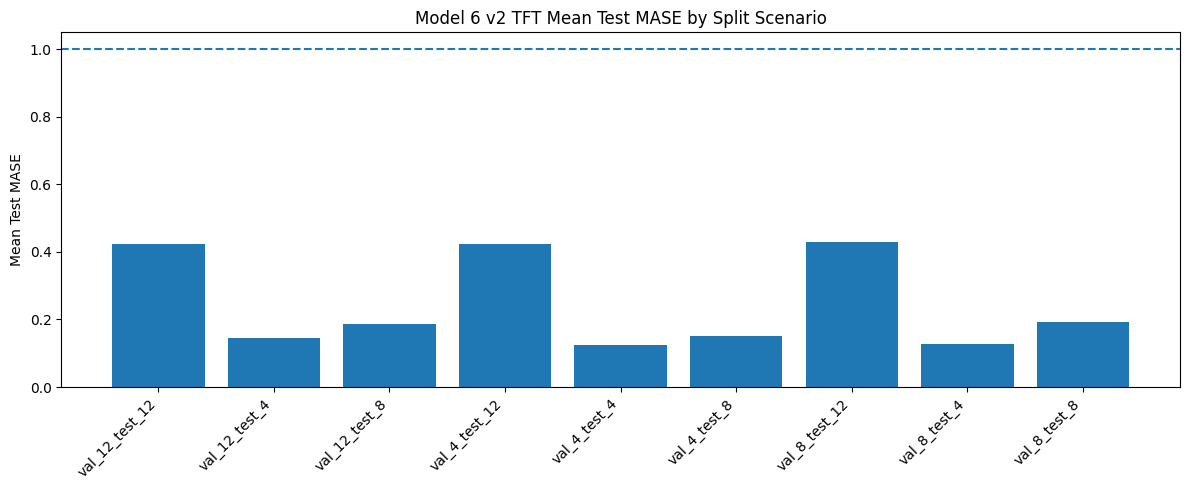

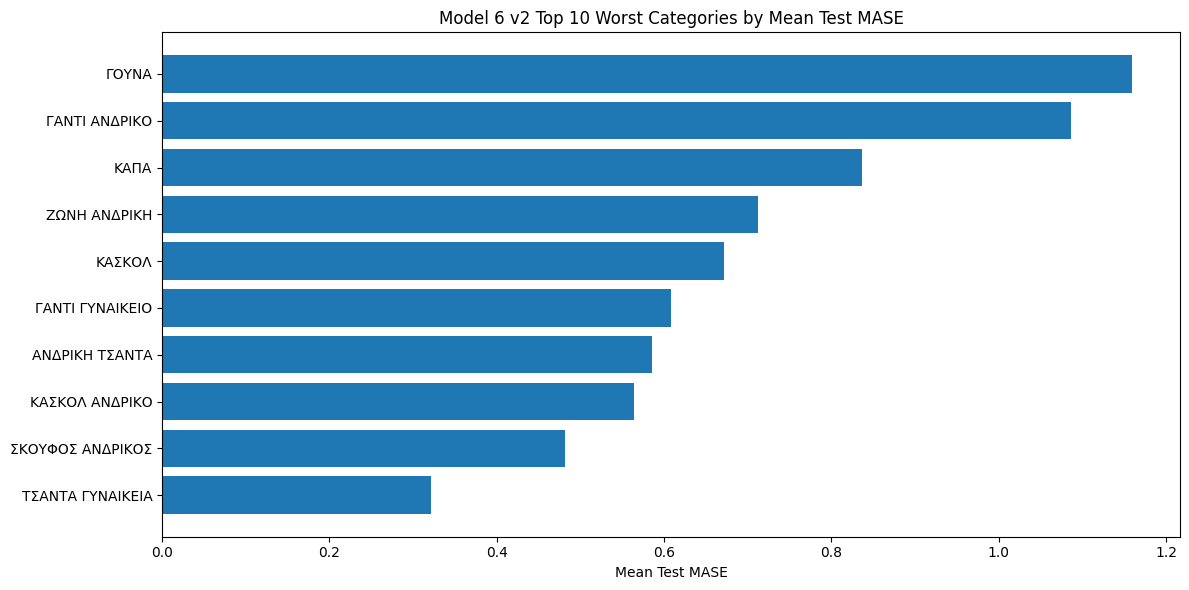

In [10]:
plt.figure(figsize=(12, 5))
plt.bar(overall["scenario"], overall["mean_MASE"])
plt.axhline(1, linestyle="--")
plt.xticks(rotation=45, ha="right")
plt.title("Model 6 v2 TFT Mean Test MASE by Split Scenario")
plt.ylabel("Mean Test MASE")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_6_v2_test_mase_by_split.png", dpi=150)
plt.show()


category_summary = (
    results_df.groupby(CATEGORY_COL, as_index=False)
    .agg(mean_MASE=("MASE", "mean"))
    .sort_values("mean_MASE", ascending=False)
)

plt.figure(figsize=(12, 6))
plt.barh(category_summary[CATEGORY_COL].head(10), category_summary["mean_MASE"].head(10))
plt.gca().invert_yaxis()
plt.title("Model 6 v2 Top 10 Worst Categories by Mean Test MASE")
plt.xlabel("Mean Test MASE")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_6_v2_top_10_worst_categories.png", dpi=150)
plt.show()

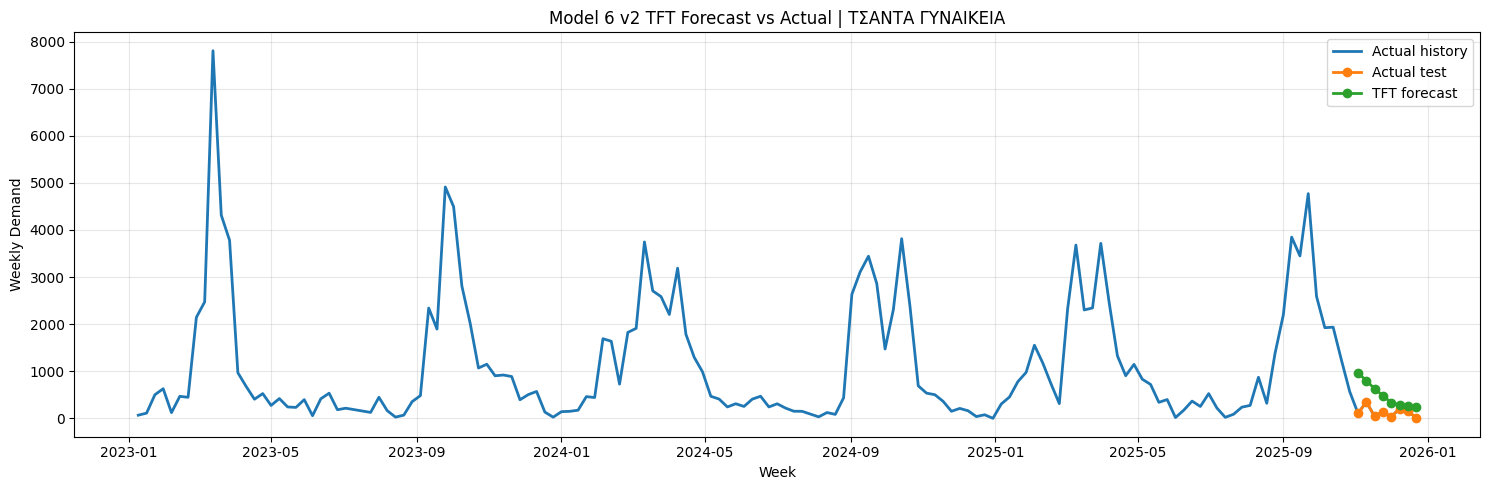

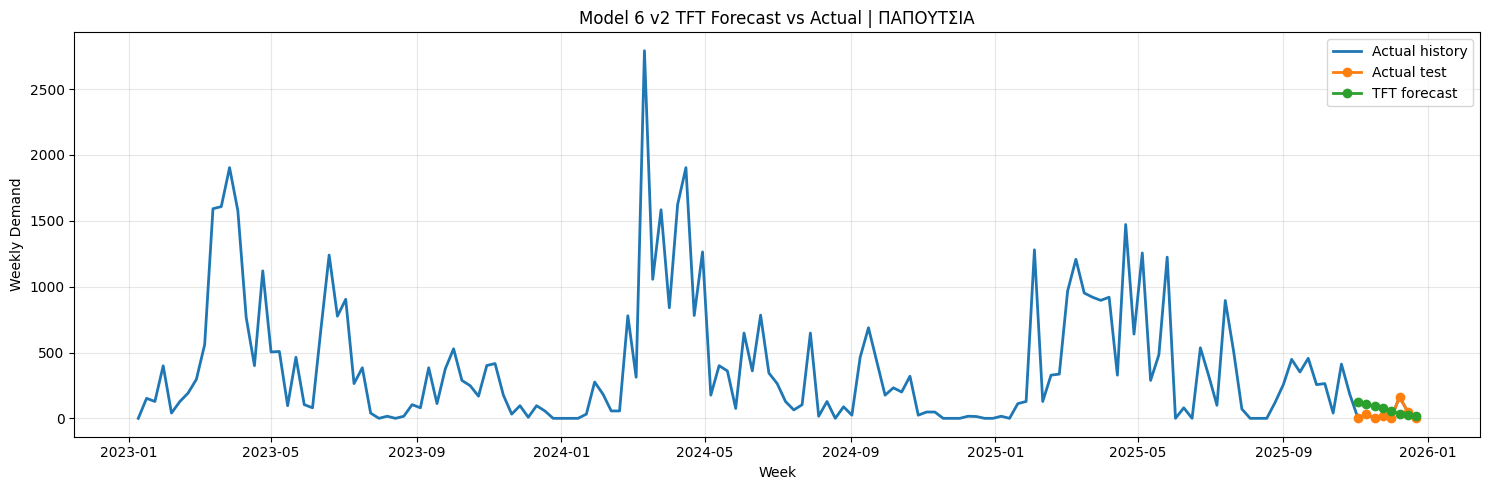

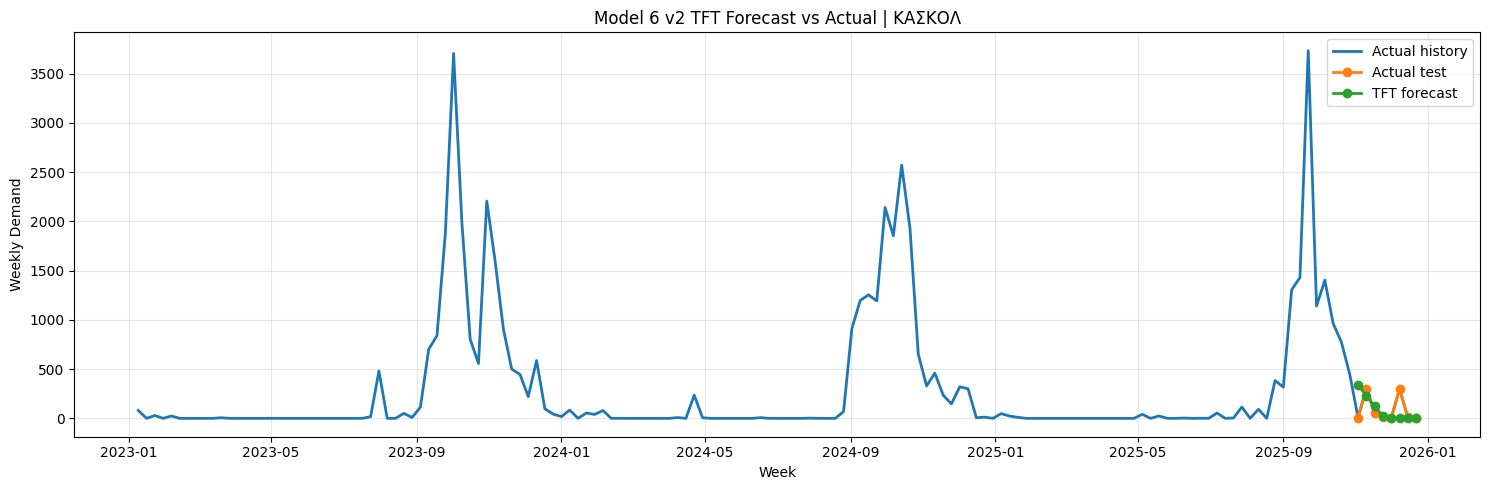

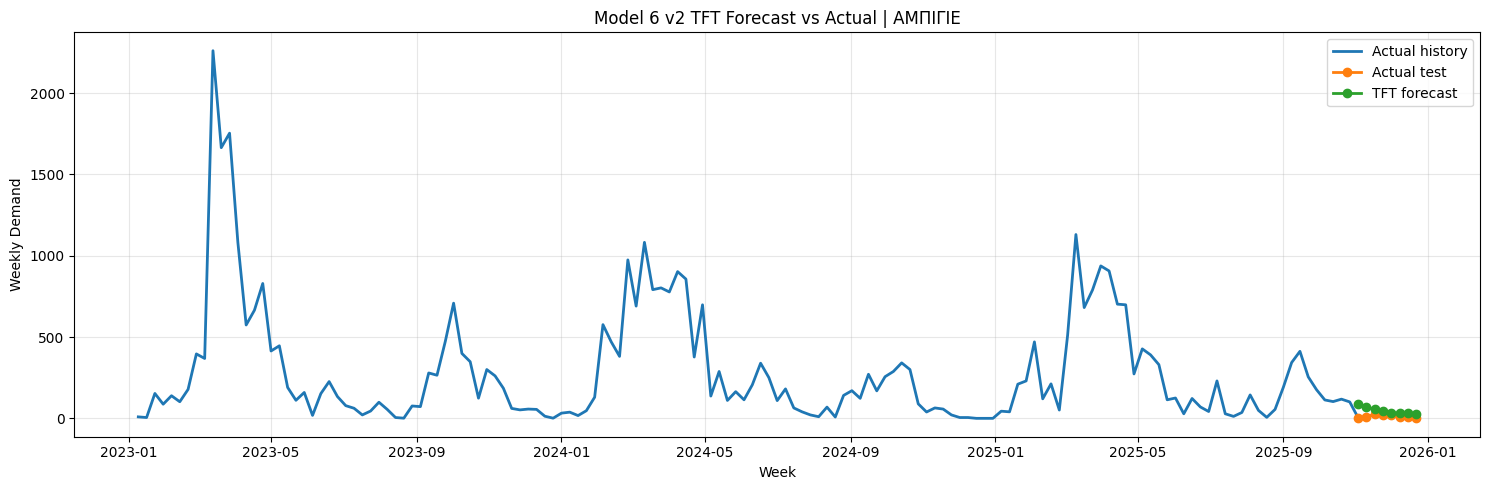

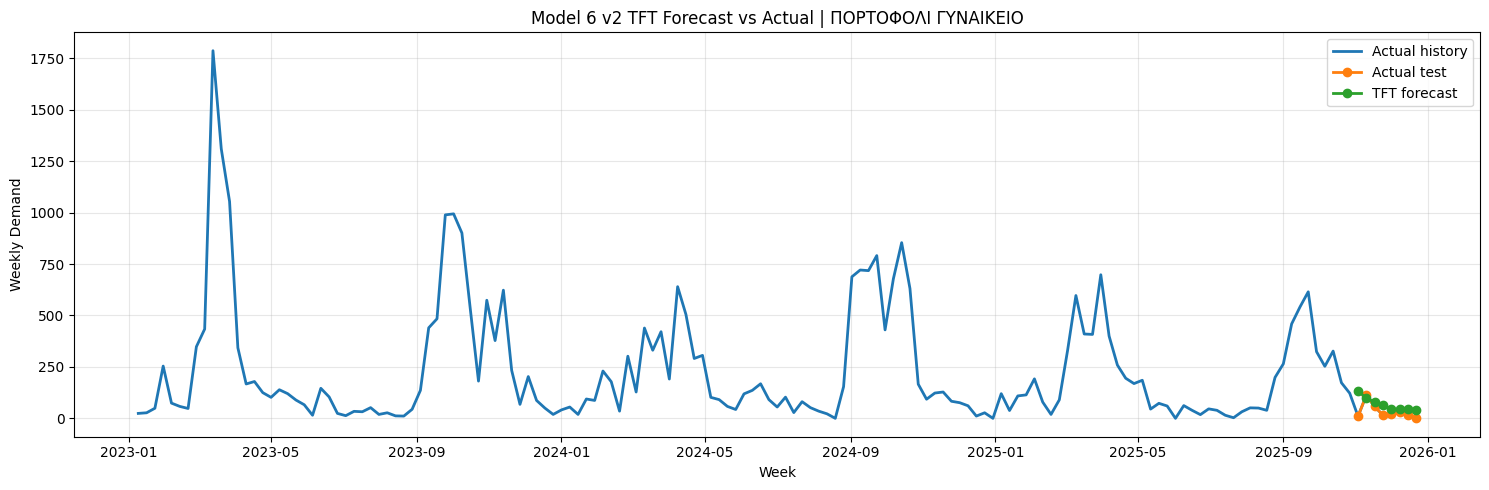

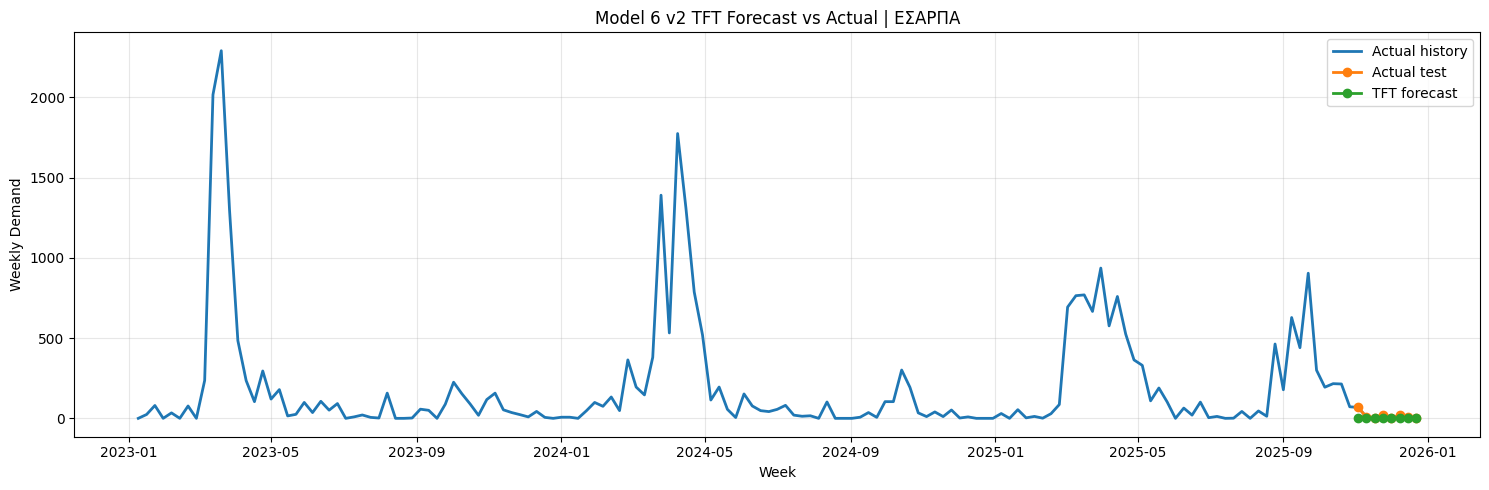

In [11]:
plot_scenario = "val_8_test_8"

if "predictions_df" not in globals():
    raise NameError("predictions_df does not exist. Run Section 8 first.")

required_pred_cols = ["scenario", CATEGORY_COL, "week", "actual", "prediction"]
missing_pred_cols = [c for c in required_pred_cols if c not in predictions_df.columns]

if missing_pred_cols:
    raise ValueError(f"Missing columns in predictions_df: {missing_pred_cols}")

top_categories = (
    weekly.groupby(CATEGORY_COL)["target"]
    .sum()
    .sort_values(ascending=False)
    .head(6)
    .index
    .tolist()
)

for cat in top_categories:
    actual_cat = (
        weekly[weekly[CATEGORY_COL] == cat]
        .groupby("week", as_index=False)["target"]
        .sum()
        .sort_values("week")
    )

    pred_cat = (
        predictions_df[
            (predictions_df["scenario"] == plot_scenario) &
            (predictions_df[CATEGORY_COL] == cat)
        ]
        .groupby("week", as_index=False)
        .agg(
            prediction=("prediction", "sum"),
            actual_test=("actual", "sum")
        )
        .sort_values("week")
    )

    if pred_cat.empty:
        print(f"Skipping {cat}: no predictions found for {plot_scenario}")
        continue

    plt.figure(figsize=(15, 5))

    plt.plot(
        actual_cat["week"],
        actual_cat["target"],
        label="Actual history",
        linewidth=2
    )

    plt.plot(
        pred_cat["week"],
        pred_cat["actual_test"],
        marker="o",
        label="Actual test",
        linewidth=2
    )

    plt.plot(
        pred_cat["week"],
        pred_cat["prediction"],
        marker="o",
        label="TFT forecast",
        linewidth=2
    )

    plt.title(f"Model 6 v2 TFT Forecast vs Actual | {cat}")
    plt.ylabel("Weekly Demand")
    plt.xlabel("Week")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    safe_cat = re.sub(r"[^A-Za-zΑ-Ωα-ω0-9_]+", "_", str(cat))
    plt.savefig(
        OUTPUT_DIR / f"model_6_v2_forecast_vs_actual_{safe_cat}.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

TFT native interpretation saved.


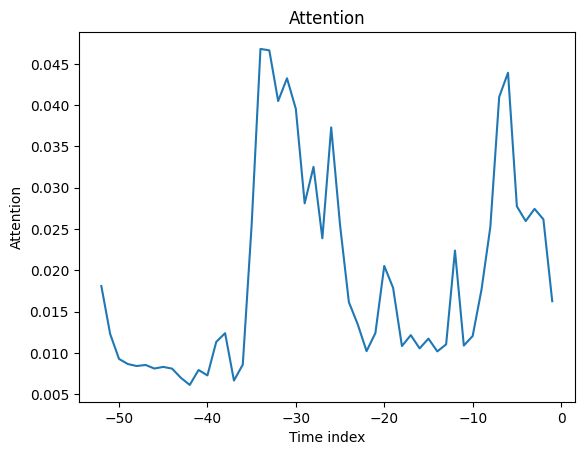

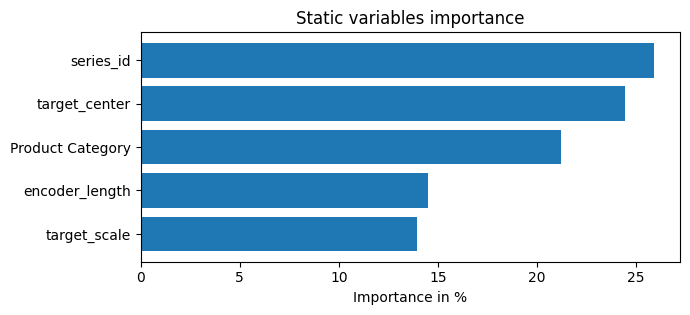

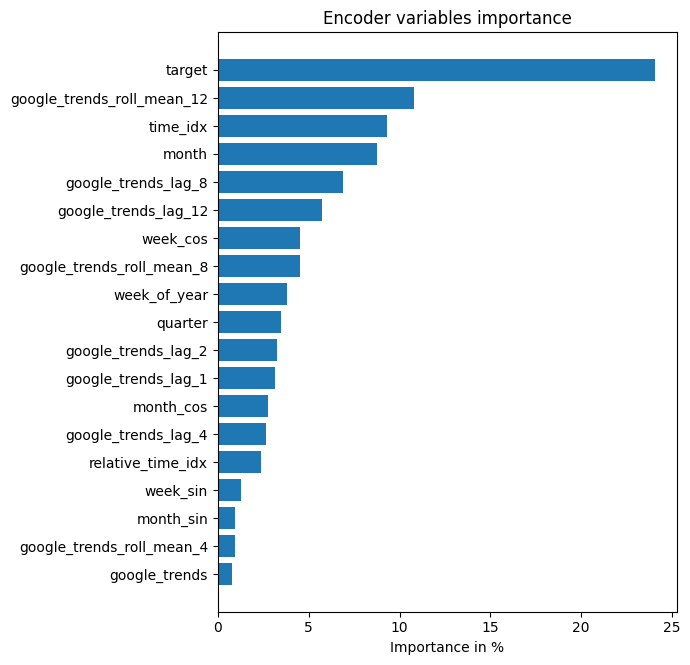

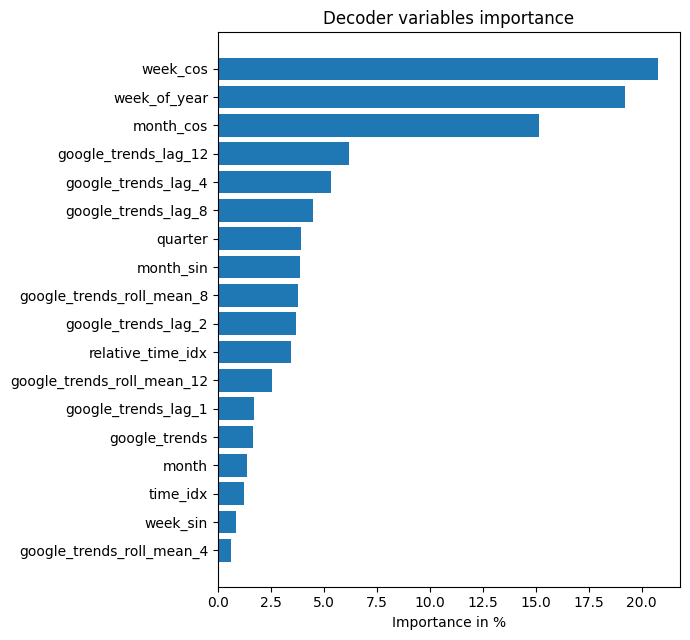

In [12]:
scenario_for_interpretation = "val_8_test_8"

if scenario_for_interpretation not in best_models:
    raise KeyError(f"{scenario_for_interpretation} not found in best_models.")

best_tft = best_models[scenario_for_interpretation]["model"]
test_loader = best_models[scenario_for_interpretation]["test_loader"]

raw_predictions = best_tft.predict(
    test_loader,
    mode="raw",
    return_x=True
)

interpretation = best_tft.interpret_output(
    raw_predictions.output,
    reduction="sum"
)

figures = best_tft.plot_interpretation(interpretation)

if isinstance(figures, dict):
    for name, fig in figures.items():
        if hasattr(fig, "savefig"):
            fig.savefig(
                OUTPUT_DIR / f"model_6_v2_tft_interpretation_{name}.png",
                dpi=150,
                bbox_inches="tight"
            )

elif isinstance(figures, list):
    for i, fig in enumerate(figures):
        if hasattr(fig, "savefig"):
            fig.savefig(
                OUTPUT_DIR / f"model_6_v2_tft_interpretation_{i}.png",
                dpi=150,
                bbox_inches="tight"
            )

else:
    if hasattr(figures, "savefig"):
        figures.savefig(
            OUTPUT_DIR / "model_6_v2_tft_interpretation.png",
            dpi=150,
            bbox_inches="tight"
        )

print("TFT native interpretation saved.")

SHAP feature columns used: 34
['time_idx', 'month', 'quarter', 'week_of_year', 'week_sin', 'week_cos', 'month_sin', 'month_cos', 'google_trends', 'google_trends_lag_1', 'google_trends_lag_2', 'google_trends_lag_4', 'google_trends_lag_8', 'google_trends_lag_12', 'google_trends_roll_mean_4', 'google_trends_roll_mean_8', 'google_trends_roll_mean_12', 'target_lag_1', 'target_lag_2', 'target_lag_4', 'target_lag_8', 'target_lag_12', 'target_lag_26', 'target_lag_52', 'target_roll_mean_4', 'target_roll_mean_8', 'target_roll_mean_12', 'target_roll_mean_26', 'target_roll_mean_52', 'target_roll_std_4', 'target_roll_std_8', 'target_roll_std_12', 'target_roll_std_26', 'target_roll_std_52']
X_train: (5240, 74) [dtype('float64')]
X_test: (960, 74) [dtype('float64')]


Surrogate MAE: 41.97888978275781
Surrogate RMSE: 161.337254366886


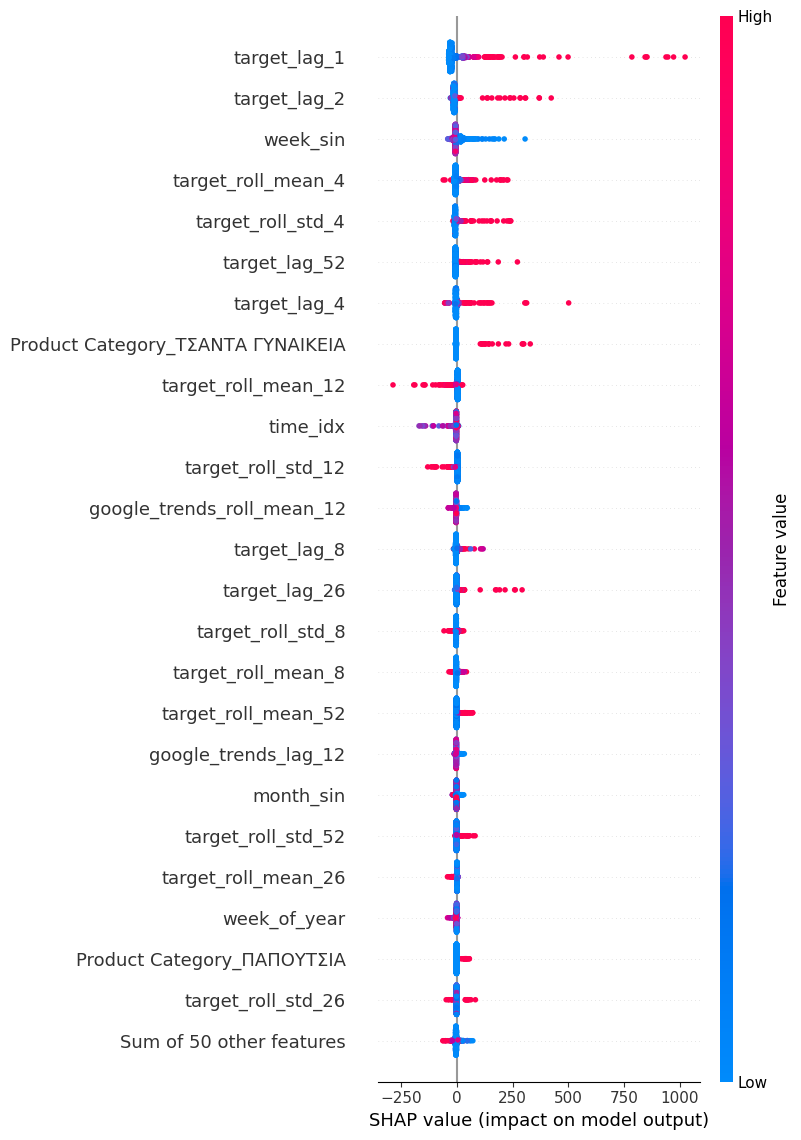

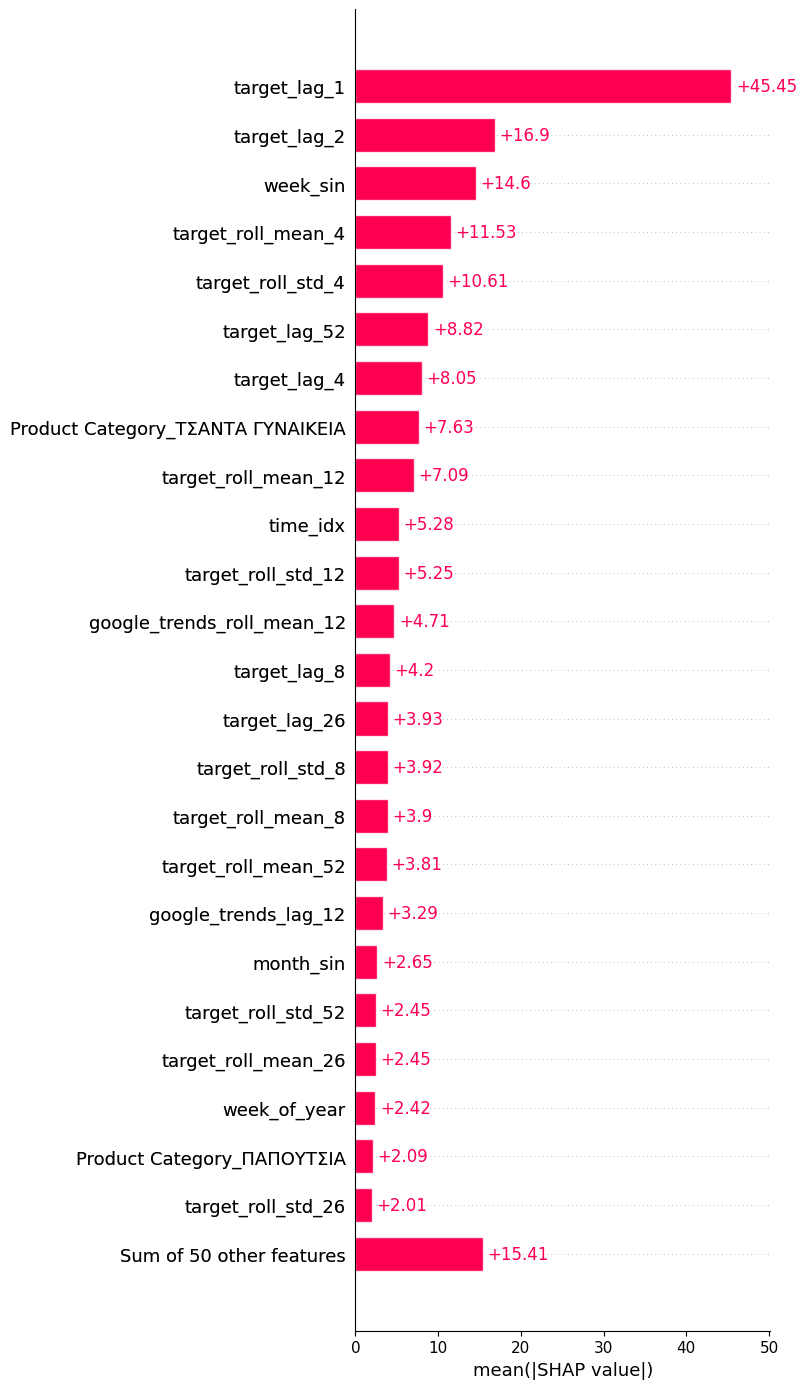

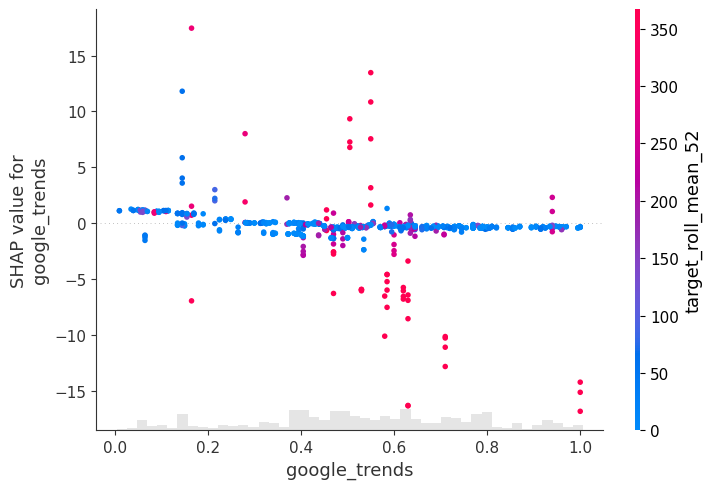

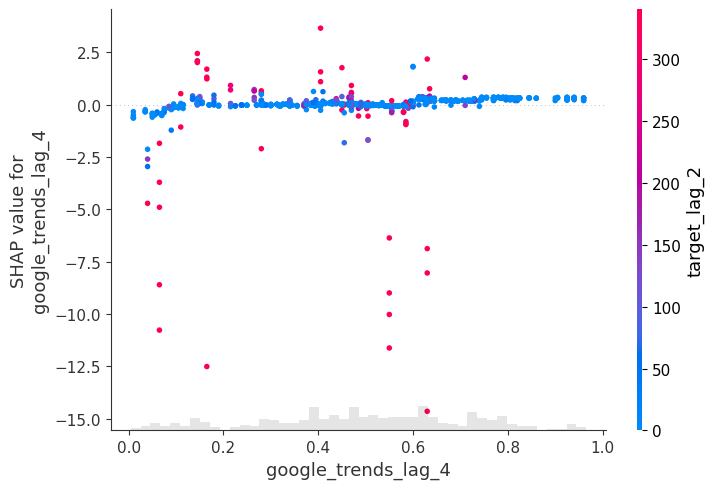

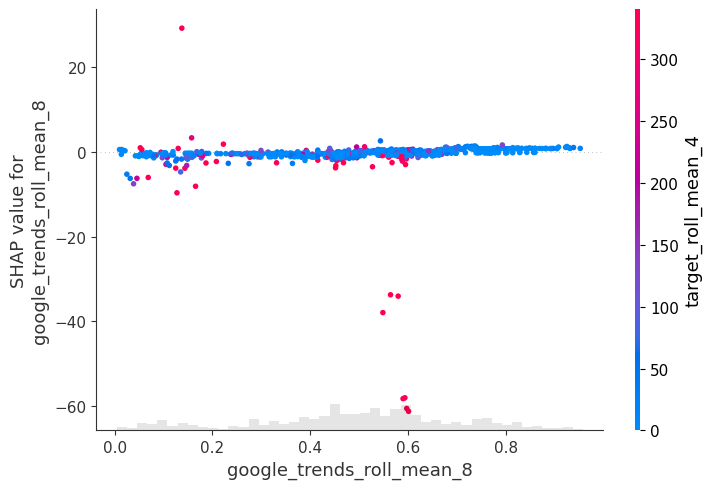

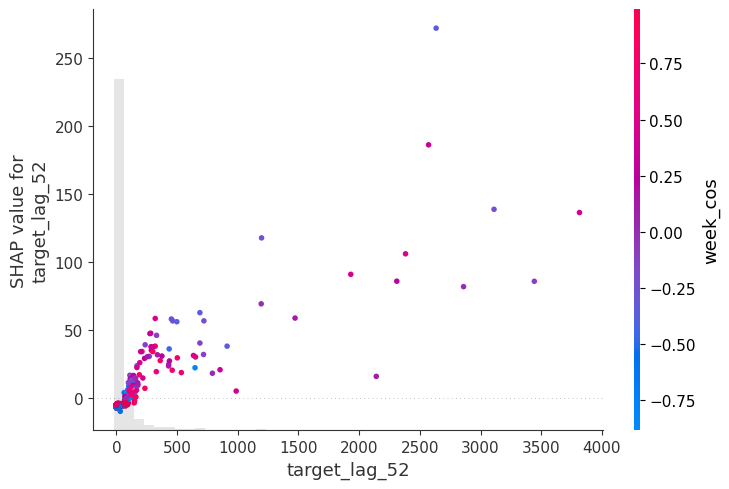

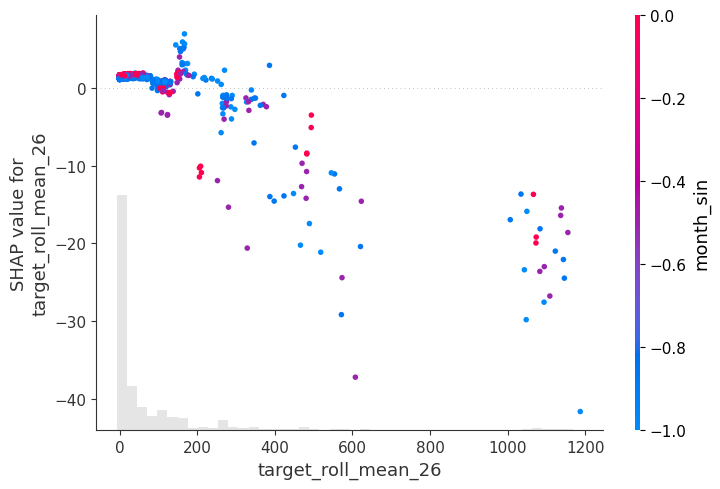

,feature,mean_abs_shap
17,target_lag_1,45.448348
18,target_lag_2,16.897376
4,week_sin,14.603018
24,target_roll_mean_4,11.526379
29,target_roll_std_4,10.610789
23,target_lag_52,8.816074
19,target_lag_4,8.047325
68,Product Category_ΤΣΑΝΤΑ ΓΥΝΑΙΚΕΙΑ,7.634618
26,target_roll_mean_12,7.086662
0,time_idx,5.275421


In [13]:
shap_df = weekly.copy()

for lag in [1, 2, 4, 8, 12, 26, 52]:
    shap_df[f"target_lag_{lag}"] = (
        shap_df.groupby("series_id")["target"].shift(lag)
    )

for window in [4, 8, 12, 26, 52]:
    shap_df[f"target_roll_mean_{window}"] = (
        shap_df.groupby("series_id")["target"]
               .shift(1)
               .rolling(window)
               .mean()
               .reset_index(level=0, drop=True)
    )

    shap_df[f"target_roll_std_{window}"] = (
        shap_df.groupby("series_id")["target"]
               .shift(1)
               .rolling(window)
               .std()
               .reset_index(level=0, drop=True)
    )

shap_df = shap_df.replace([np.inf, -np.inf], np.nan).fillna(0)

candidate_feature_cols = [
    "time_idx",
    "month",
    "quarter",
    "week_of_year",
    "week_sin",
    "week_cos",
    "month_sin",
    "month_cos",

    "google_trends",
    "google_trends_lag_1",
    "google_trends_lag_2",
    "google_trends_lag_4",
    "google_trends_lag_8",
    "google_trends_lag_12",
    "google_trends_roll_mean_4",
    "google_trends_roll_mean_8",
    "google_trends_roll_mean_12",

    "weekly_revenue",
    "transaction_count",
    "unique_skus",
    "unique_customers",
    "avg_unit_price",
    "avg_gross_margin_pct",
    "negative_margin_share",
    "from_china_share",
    "from_india_share",

    "target_lag_1",
    "target_lag_2",
    "target_lag_4",
    "target_lag_8",
    "target_lag_12",
    "target_lag_26",
    "target_lag_52",

    "target_roll_mean_4",
    "target_roll_mean_8",
    "target_roll_mean_12",
    "target_roll_mean_26",
    "target_roll_mean_52",

    "target_roll_std_4",
    "target_roll_std_8",
    "target_roll_std_12",
    "target_roll_std_26",
    "target_roll_std_52",
]

feature_cols = [c for c in candidate_feature_cols if c in shap_df.columns]

print("SHAP feature columns used:", len(feature_cols))
print(feature_cols)

cat_encoded = pd.get_dummies(
    shap_df[[CATEGORY_COL]],
    drop_first=False,
    dtype=float
)

X = pd.concat(
    [
        shap_df[feature_cols].reset_index(drop=True),
        cat_encoded.reset_index(drop=True)
    ],
    axis=1
)

X = X.apply(pd.to_numeric, errors="coerce")
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
X = X.astype(np.float64)

y = pd.to_numeric(shap_df["target"], errors="coerce").fillna(0).astype(np.float64)

if "train_cutoff" not in globals():
    max_time = shap_df["time_idx"].max()
    train_cutoff = max_time - 16

train_mask = shap_df["time_idx"] <= train_cutoff
test_mask = shap_df["time_idx"] > train_cutoff

X_train, y_train = X.loc[train_mask.values], y.loc[train_mask.values]
X_test, y_test = X.loc[test_mask.values], y.loc[test_mask.values]

print("X_train:", X_train.shape, X_train.dtypes.unique())
print("X_test:", X_test.shape, X_test.dtypes.unique())

surrogate = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
)

surrogate.fit(X_train, y_train)

surrogate_pred = surrogate.predict(X_test)

print("Surrogate MAE:", mean_absolute_error(y_test, surrogate_pred))
print("Surrogate RMSE:", np.sqrt(mean_squared_error(y_test, surrogate_pred)))

background = X_train.sample(min(200, len(X_train)), random_state=42)
X_shap = X_test.sample(min(800, len(X_test)), random_state=42)

explainer = shap.TreeExplainer(
    surrogate,
    data=background,
    feature_perturbation="interventional"
)

shap_values_array = explainer.shap_values(X_shap)

shap_values = shap.Explanation(
    values=shap_values_array,
    base_values=np.repeat(explainer.expected_value, X_shap.shape[0]),
    data=X_shap.values,
    feature_names=X_shap.columns.tolist()
)

shap.plots.beeswarm(
    shap_values,
    max_display=25,
    show=False
)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "model_6_v2_shap_beeswarm.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

shap.plots.bar(
    shap_values,
    max_display=25,
    show=False
)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "model_6_v2_shap_bar.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

important_dependence_features = [
    "google_trends",
    "google_trends_lag_4",
    "google_trends_roll_mean_8",
    "target_lag_52",
    "target_roll_mean_26",
]

for f in important_dependence_features:
    if f in X_shap.columns:
        shap.plots.scatter(
            shap_values[:, f],
            color=shap_values,
            show=False
        )
        plt.tight_layout()
        plt.savefig(
            OUTPUT_DIR / f"model_6_v2_shap_dependence_{f}.png",
            dpi=150,
            bbox_inches="tight"
        )
        plt.show()

shap_importance = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values.values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

shap_importance.to_csv(
    OUTPUT_DIR / "model_6_v2_shap_feature_importance.csv",
    index=False
)

display(shap_importance.head(30))

Model 6 Mean Test MASE: 0.2443
Best Previous Model MASE: 0.3900
Improvement: 37.37%


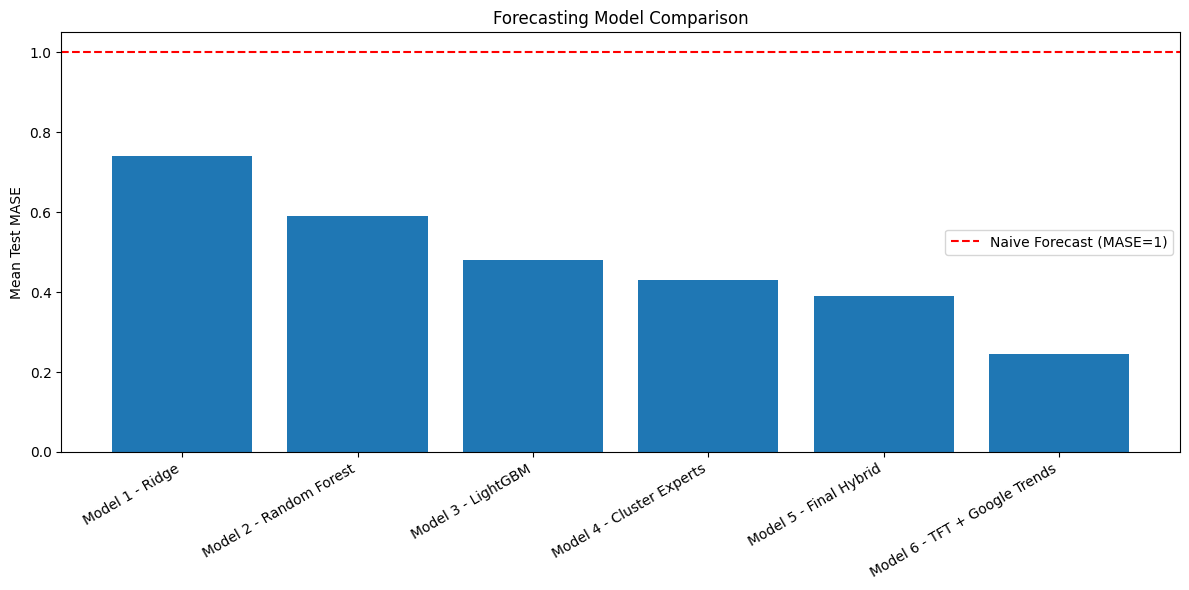

,Model,Mean Test MASE
5,Model 6 - TFT + Google Trends,0.244257
4,Model 5 - Final Hybrid,0.390000
3,Model 4 - Cluster Experts,0.430000
2,Model 3 - LightGBM,0.480000
1,Model 2 - Random Forest,0.590000
0,Model 1 - Ridge,0.740000


In [14]:
previous_models = pd.DataFrame({
    "Model": [
        "Model 1 - Ridge",
        "Model 2 - Random Forest",
        "Model 3 - LightGBM",
        "Model 4 - Cluster Experts",
        "Model 5 - Final Hybrid"
    ],
    "Mean Test MASE": [
        0.74,
        0.59,
        0.48,
        0.43,
        0.39
    ]
})

model_6_score = results_df["MASE"].mean()

comparison = pd.concat([
    previous_models,
    pd.DataFrame({
        "Model": ["Model 6 - TFT + Google Trends"],
        "Mean Test MASE": [model_6_score]
    })
], ignore_index=True)

best_previous = previous_models["Mean Test MASE"].min()

improvement_pct = (
    (best_previous - model_6_score)
    / best_previous
) * 100

print(f"Model 6 Mean Test MASE: {model_6_score:.4f}")
print(f"Best Previous Model MASE: {best_previous:.4f}")
print(f"Improvement: {improvement_pct:.2f}%")

comparison.to_excel(
    OUTPUT_DIR / "model_6_final_comparison.xlsx",
    index=False
)

plt.figure(figsize=(12,6))

bars = plt.bar(
    comparison["Model"],
    comparison["Mean Test MASE"]
)

plt.axhline(
    y=1,
    linestyle="--",
    color="red",
    label="Naive Forecast (MASE=1)"
)

plt.ylabel("Mean Test MASE")
plt.title("Forecasting Model Comparison")

plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "model_6_final_comparison.png",
    dpi=150
)

plt.show()

display(comparison.sort_values("Mean Test MASE"))

In [15]:
excel_path = OUTPUT_DIR / "model_6_v2_all_results.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:

    if "weekly" in globals():
        weekly.to_excel(
            writer,
            sheet_name="Dataset",
            index=False
        )

    if "results_df" in globals():
        results_df.to_excel(
            writer,
            sheet_name="Category_Metrics",
            index=False
        )

    if "overall" in globals():
        overall.to_excel(
            writer,
            sheet_name="Overall_Summary",
            index=False
        )

    if "predictions_df" in globals():
        predictions_df.to_excel(
            writer,
            sheet_name="Predictions",
            index=False
        )

    if "comparison" in globals():
        comparison.to_excel(
            writer,
            sheet_name="Model_Comparison",
            index=False
        )

    if "shap_importance" in globals():
        shap_importance.to_excel(
            writer,
            sheet_name="SHAP_Importance",
            index=False
        )

print("Saved successfully:")
print(excel_path)

Saved successfully:
/content/drive/MyDrive/model_6_tft_v2_outputs/model_6_v2_all_results.xlsx
